In [16]:
import numpy as np
import pickle 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, roc_curve, auc)
from sklearn.ensemble import RandomForestClassifier

## TRAINING NAIVE BAYES

### Loading Data 

In [17]:
X_train = np.load("data/X_train_tfidf.npy")
X_test  = np.load("data/X_test_tfidf.npy")
y_train = np.load("data/y_train.npy")
y_test  = np.load("data/y_test.npy")

# print(X_train)

# print(f"   X_train : {X_train.shape}")
# print(f"   X_test  : {X_test.shape}")

### Training Model

In [18]:
X_train = np.clip(X_train, 0, None)
X_test = np.clip(X_test, 0, None)

nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train, y_train)

y_pred = nb_model.predict(X_test)
y_pred_proba = nb_model.predict_proba(X_test)

y_scores = y_pred_proba[:, 1]

### Classification Metrics

In [19]:
accuracy = accuracy_score(y_test, y_pred)

report = classification_report(y_test, y_pred, target_names=['Real (0)', 'Fake (1)'])

cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)   ## Recall for the FAKE class
specificity = tn / (tn + fp)   ## Recall for the REAL class

fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)


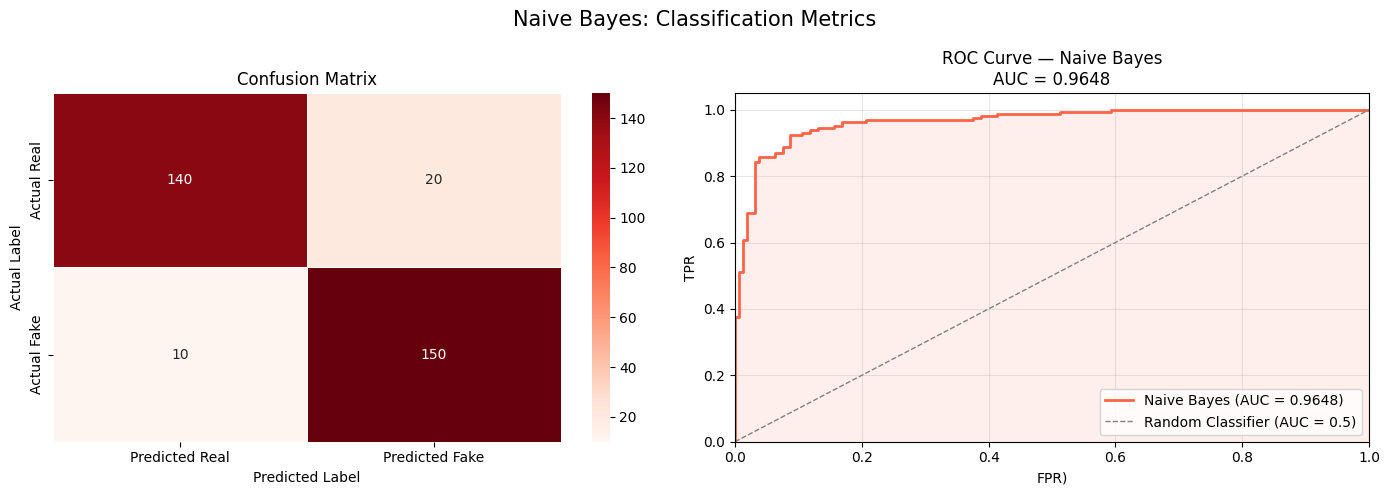

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Naive Bayes: Classification Metrics", fontsize=15)

## Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Predicted Real', 'Predicted Fake'], yticklabels=['Actual Real','Actual Fake'], ax=axes[0], linewidths=0.5)
axes[0].set_title("Confusion Matrix")
axes[0].set_ylabel("Actual Label")
axes[0].set_xlabel("Predicted Label")

## ROC curve
axes[1].plot(fpr, tpr, color='tomato', lw=2, label=f'Naive Bayes (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier (AUC = 0.5)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='tomato')

axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel("FPR)")
axes[1].set_ylabel("TPR")
axes[1].set_title(f"ROC Curve — Naive Bayes\nAUC = {roc_auc:.4f}")
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plots/nb_evaluation.png", dpi=150, bbox_inches='tight')
plt.show()


### Saving model and results

In [21]:
pickle.dump(nb_model, open("saved_models/nb_model.pkl", "wb"))

nb_results = {'model':'Naive Bayes','accuracy':accuracy,'sensitivity': sensitivity,'specificity': specificity,'auc': roc_auc,'fpr': fpr,'tpr': tpr,'cm': cm}

pickle.dump(nb_results, open("saved_models/nb_results.pkl", "wb"))

## TRAINING SVM

### Training data

In [22]:
base_svm = LinearSVC(C=1.0, max_iter=2000, random_state=42)

svm_model = CalibratedClassifierCV(base_svm, cv = 5)

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)
y_pred_proba = svm_model.predict_proba(X_test)
y_scores = y_pred_proba[:, 1]     

### Classification Metrics

In [23]:
accuracy = accuracy_score(y_test, y_pred)

report = classification_report(y_test, y_pred, target_names=['Real (0)', 'Fake (1)'])

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

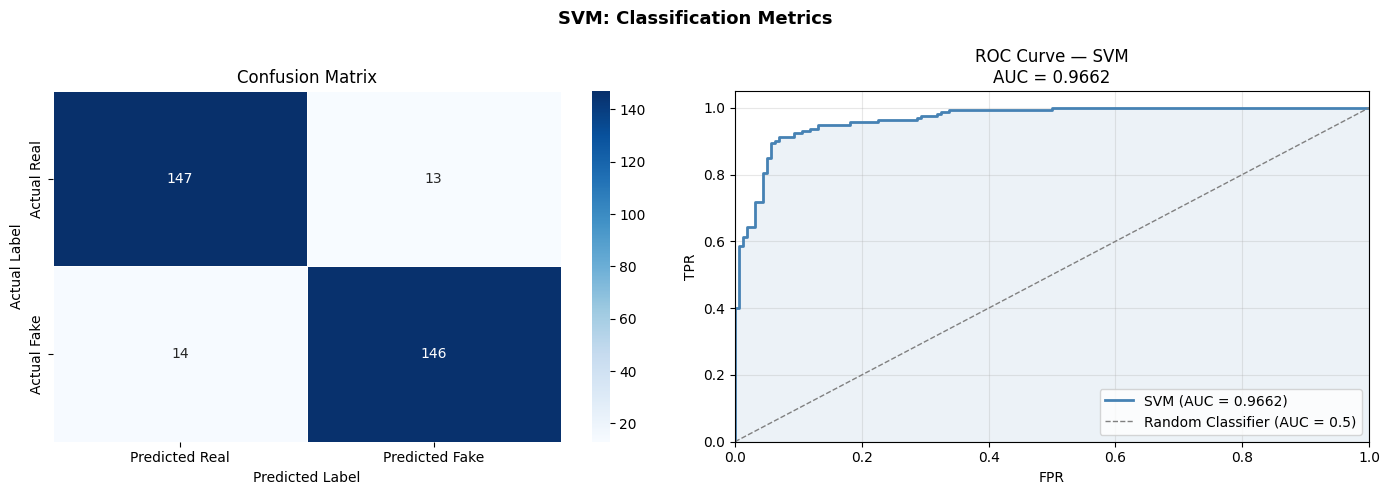

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("SVM: Classification Metrics", fontsize=13, fontweight='bold')

## Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Real', 'Predicted Fake'], yticklabels=['Actual Real','Actual Fake'], ax=axes[0], linewidths=0.5)
axes[0].set_title("Confusion Matrix")
axes[0].set_ylabel("Actual Label")
axes[0].set_xlabel("Predicted Label")

## ROC Curve 
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'SVM (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier (AUC = 0.5)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')

axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel("FPR")
axes[1].set_ylabel("TPR")
axes[1].set_title(f"ROC Curve — SVM\nAUC = {roc_auc:.4f}")
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plots/svm_evaluation.png", dpi=150, bbox_inches='tight')
plt.show()


### Saving model

In [25]:
pickle.dump(svm_model, open("saved_models/svm_model.pkl", "wb"))

svm_results = {'model':'SVM','accuracy':accuracy,'sensitivity': sensitivity,'specificity': specificity,'auc': roc_auc,'fpr': fpr,'tpr': tpr,'cm': cm}

pickle.dump(svm_results, open("saved_models/svm_results.pkl", "wb"))

## TRAINING RANDOM FOREST

### Training model

In [26]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=None, max_features='sqrt', random_state=42, n_jobs=-1)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_scores_rf  = rf_model.predict_proba(X_test)[:, 1]

accuracy_rf = accuracy_score(y_test, y_pred_rf)

cm_rf = confusion_matrix(y_test, y_pred_rf)
tp, fp, tn, fn = cm_rf.ravel()

sensitivity_rf = tp / (tp + fn)
specificity_rf = tn / (tn + fp)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_scores_rf)
auc_rf = auc(fpr_rf, tpr_rf)

### RF Visualization and comparison

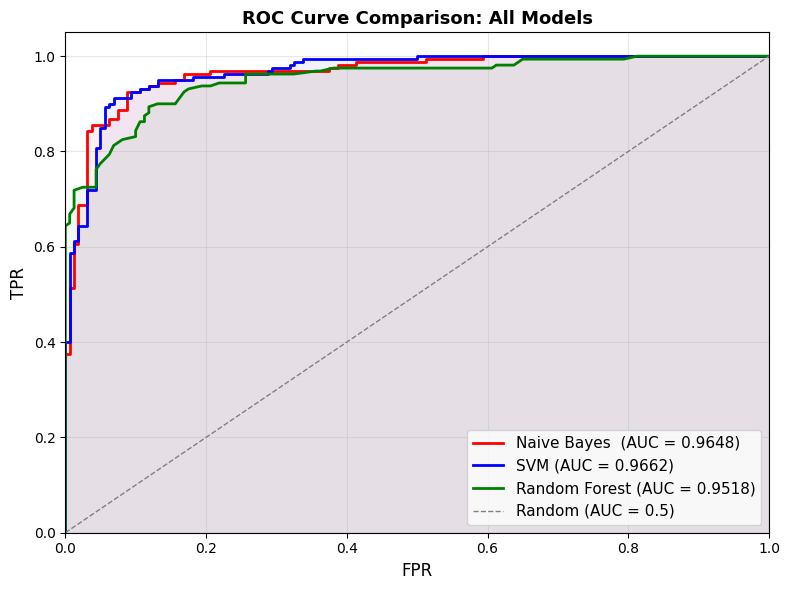

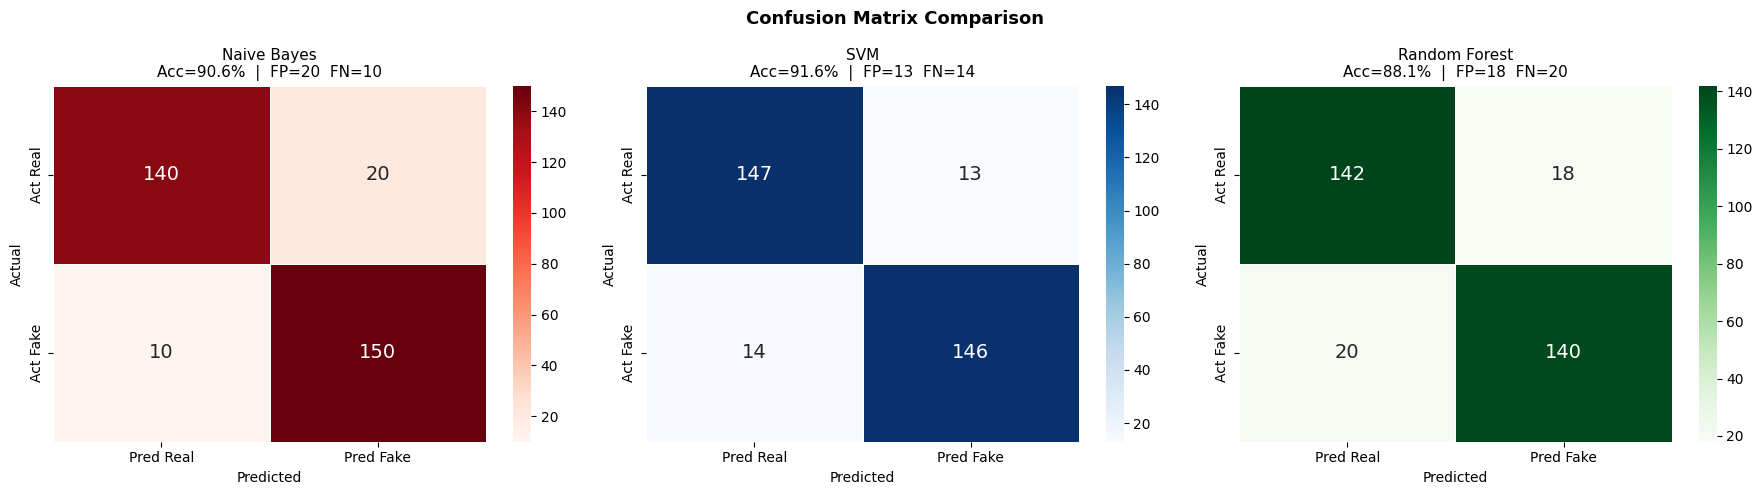

In [27]:
## Comparative ROC curve
fig1, ax = plt.subplots(figsize=(8, 6))

ax.plot(nb_results['fpr'],  nb_results['tpr'], color='red', lw=2, label=f"Naive Bayes  (AUC = {nb_results['auc']:.4f})")
ax.plot(svm_results['fpr'], svm_results['tpr'], color='blue', lw=2, label=f"SVM (AUC = {svm_results['auc']:.4f})")
ax.plot(fpr_rf, tpr_rf, color='green',  lw=2, label=f"Random Forest (AUC = {auc_rf:.4f})")
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random (AUC = 0.5)')

ax.fill_between(nb_results['fpr'],  nb_results['tpr'],  alpha=0.05, color='red')
ax.fill_between(svm_results['fpr'], svm_results['tpr'], alpha=0.05, color='blue')
ax.fill_between(fpr_rf, tpr_rf, alpha=0.05, color='green')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("FPR", fontsize=12)
ax.set_ylabel("TPR", fontsize=12)
ax.set_title("ROC Curve Comparison: All Models", fontsize=13, fontweight='bold')
ax.legend(loc="lower right", fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plots/roc_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

## Confusion Matrix Comparison

fig2, axes = plt.subplots(1, 3, figsize=(18, 5))
fig2.suptitle("Confusion Matrix Comparison", fontsize=13, fontweight='bold')

models_cms = [("Naive Bayes",nb_results['cm'],'Reds'),("SVM",svm_results['cm'], 'Blues'), ("Random Forest", cm_rf,'Greens'),]

for ax, (name, cm, cmap) in zip(axes, models_cms):
    tn_, fp_, fn_, tp_ = cm.ravel()
    acc = (tp_ + tn_) / (tp_ + tn_ + fp_ + fn_)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=['Pred Real', 'Pred Fake'], yticklabels=['Act Real', 'Act Fake'], ax=ax, 
                linewidths=0.5, annot_kws={"size": 14})
    ax.set_title(f"{name}\nAcc={acc*100:.1f}%  |  " f"FP={fp_}  FN={fn_}", fontsize=11)
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.tight_layout()
plt.savefig("plots/cm_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

## Saving model and results

In [28]:
pickle.dump(rf_model, open("saved_models/rf_model.pkl", "wb"))

rf_results = {
    'model'      : 'Random Forest',
    'accuracy'   : accuracy_rf,
    'sensitivity': sensitivity_rf,
    'specificity': specificity_rf,
    'auc'        : auc_rf,
    'fpr'        : fpr_rf,
    'tpr'        : tpr_rf,
    'cm'         : cm_rf
}
pickle.dump(rf_results, open("saved_models/rf_results.pkl", "wb"))

### Best Model

In [29]:
all_models = [ ('Naive Bayes', nb_results['accuracy'],  nb_results['auc']), ('SVM',svm_results['accuracy'], svm_results['auc']), 
              ('Random Forest', accuracy_rf,auc_rf),]

winner = max(all_models, key=lambda x: x[2])

print(f"WINNER BY AUC: {winner[0]}")
print(f"Accuracy : {winner[1]*100:.2f}%")
print(f" AUC : {winner[2]:.4f}")

WINNER BY AUC: SVM
Accuracy : 91.56%
 AUC : 0.9662
